# Air Quality & Public Health Risk Forecasting
## Notebook 01: Data Understanding & Research Question Formulation

### Research Motivation
Air pollution is a major environmental risk factor affecting public health outcomes.
This project aims to explore large-scale air quality data across U.S. counties and
formulate predictive and causal research questions that can support public health
decision-making.

### Long-Term Research Goal
Develop spatio-temporal models to forecast air quality risk patterns and their
potential health implications at county and state levels.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

plt.style.use("seaborn-v0_8")

In [2]:
DATA_PATH = "../data/raw/rows.csv"

df = pd.read_csv(DATA_PATH)
df.head()


,index,MeasureId,MeasureName,MeasureType,StratificationLevel,StateFips,StateName,CountyFips,CountyName,ReportYear,Value,Unit,UnitName,DataOrigin,MonitorOnly
0,0,83,Number of days with maximum 8-hour average ozo...,Counts,State x County,1,Alabama,1051,Elmore,1999,5.0,No Units,No Units,Monitor Only,1
1,1,83,Number of days with maximum 8-hour average ozo...,Counts,State x County,1,Alabama,1073,Jefferson,1999,39.0,No Units,No Units,Monitor Only,1
2,2,83,Number of days with maximum 8-hour average ozo...,Counts,State x County,1,Alabama,1079,Lawrence,1999,28.0,No Units,No Units,Monitor Only,1
3,3,83,Number of days with maximum 8-hour average ozo...,Counts,State x County,1,Alabama,1089,Madison,1999,31.0,No Units,No Units,Monitor Only,1
4,4,83,Number of days with maximum 8-hour average ozo...,Counts,State x County,1,Alabama,1097,Mobile,1999,32.0,No Units,No Units,Monitor Only,1


In [26]:
print("Checking Units per Measure:")
print(df.groupby("MeasureName")["UnitName"].unique())

Checking Units per Measure:
MeasureName
Annual average ambient concentrations of PM 2.5 in micrograms per cubic meter, based on seasonal averages and daily measurement (monitor and modeled data)    [Micograms per cubic meter]
Annual average ambient concentrations of PM2.5 in micrograms per cubic meter (based on seasonal averages and daily measurement)                               [Micograms per cubic meter]
Number of days with maximum 8-hour average ozone concentration over the National Ambient Air Quality Standard                                                                  [No Units]
Number of days with maximum 8-hour average ozone concentration over the National Ambient Air Quality Standard (monitor and modeled data)                                       [No Units]
Number of person-days with PM2.5 over the National Ambient Air Quality Standard (monitor and modeled data)                                                                     [No Units]
Number of person-days with max

In [4]:
df.shape

(218635, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218635 entries, 0 to 218634
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   index                218635 non-null  int64  
 1   MeasureId            218635 non-null  int64  
 2   MeasureName          218635 non-null  object 
 3   MeasureType          218635 non-null  object 
 4   StratificationLevel  218635 non-null  object 
 5   StateFips            218635 non-null  int64  
 6   StateName            218635 non-null  object 
 7   CountyFips           218635 non-null  int64  
 8   CountyName           218635 non-null  object 
 9   ReportYear           218635 non-null  int64  
 10  Value                218635 non-null  float64
 11  Unit                 218635 non-null  object 
 12  UnitName             218635 non-null  object 
 13  DataOrigin           218635 non-null  object 
 14  MonitorOnly          218635 non-null  int64  
dtypes: float64(1), in

In [6]:
df.describe()

,index,MeasureId,StateFips,CountyFips,ReportYear,Value,MonitorOnly
count,218635.00000,218635.000000,218635.000000,218635.000000,218635.000000,2.186350e+05,218635.000000
mean,109317.00000,248.436979,30.228980,30328.039536,2005.997777,6.499649e+05,0.383950
std,63114.63239,86.333124,15.139346,15157.173159,3.432221,1.160826e+07,0.486347
min,0.00000,83.000000,1.000000,1001.000000,1999.000000,0.000000e+00,0.000000
25%,54658.50000,292.000000,18.000000,18146.000000,2003.000000,0.000000e+00,0.000000
50%,109317.00000,293.000000,29.000000,29189.000000,2006.000000,2.000000e+00,0.000000
75%,163975.50000,295.000000,45.000000,45021.000000,2009.000000,1.394105e+01,1.000000
max,218634.00000,296.000000,56.000000,56045.000000,2013.000000,1.084153e+09,1.000000


### Initial Observations
- The dataset contains county-level air quality measurements across multiple years.
- Measurements include ozone-related indicators exceeding national standards.
- The data is structured by state, county, and year, enabling spatio-temporal analysis.

In [7]:
key_columns = [
    "MeasureName",
    "StateName",
    "CountyName",
    "ReportYear",
    "Value"
]

df[key_columns].head()


,MeasureName,StateName,CountyName,ReportYear,Value
0,Number of days with maximum 8-hour average ozo...,Alabama,Elmore,1999,5.0
1,Number of days with maximum 8-hour average ozo...,Alabama,Jefferson,1999,39.0
2,Number of days with maximum 8-hour average ozo...,Alabama,Lawrence,1999,28.0
3,Number of days with maximum 8-hour average ozo...,Alabama,Madison,1999,31.0
4,Number of days with maximum 8-hour average ozo...,Alabama,Mobile,1999,32.0


In [8]:
df["MeasureName"].value_counts().head()

MeasureName
Number of person-days with PM2.5 over the National Ambient Air Quality Standard (monitor and modeled data)                                                    34199
Number of days with maximum 8-hour average ozone concentration over the National Ambient Air Quality Standard (monitor and modeled data)                      34199
Annual average ambient concentrations of PM 2.5 in micrograms per cubic meter, based on seasonal averages and daily measurement (monitor and modeled data)    34199
Number of person-days with maximum 8-hour average ozone concentration over the National Ambient Air Quality Standard (monitor and modeled data)               34199
Percent of days with PM2.5 levels over the National Ambient Air Quality Standard (monitor and modeled data)                                                   34199
Name: count, dtype: int64

In [9]:
df["ReportYear"].min(), df["ReportYear"].max()

(np.int64(1999), np.int64(2013))

In [11]:
missing = df.isna().mean().sort_values(ascending=False)
missing[missing > 0]


Series([], dtype: float64)

In [20]:
missing = df.isna().mean().sort_values(ascending=False)
if missing.sum() == 0:
    print("Data is complete: No NaN values found.")
else:
    print("Missing values detected:")
    print(missing[missing > 0])

print(f"\nPercentage of data from actual monitors: {df['MonitorOnly'].mean():.2%}")

Data is complete: No NaN values found.

Percentage of data from actual monitors: 38.40%


In [12]:
df["Value"].isna().sum()

np.int64(0)

### Data Quality Notes
- Missing values in air quality measurements may correspond to monitoring gaps.
- These gaps themselves can represent a research signal rather than noise.


Targeting: Number of days with maximum 8-hour average ozone concentration over the National Ambient Air Quality Standard


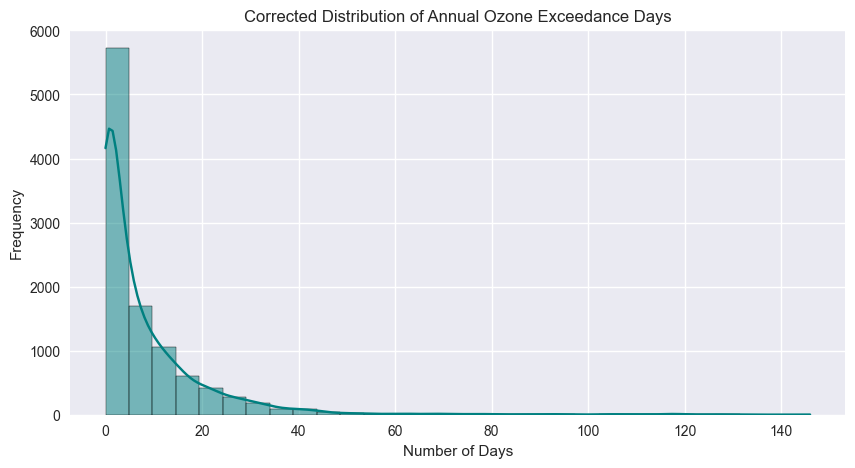

In [27]:
mask = df['MeasureName'].str.contains('Ozone', case=False) & df['MeasureName'].str.contains('days', case=False)
target_measure_name = df[mask]['MeasureName'].unique()[0]

print(f"Targeting: {target_measure_name}")

df_plot = df[df["MeasureName"] == target_measure_name].copy()

df_plot = df_plot[df_plot["Value"] <= 365]

plt.figure(figsize=(10, 5))
sns.histplot(df_plot['Value'], bins=30, kde=True, color='teal')
plt.title("Corrected Distribution of Annual Ozone Exceedance Days")
plt.xlabel("Number of Days")
plt.ylabel("Frequency")
plt.show()

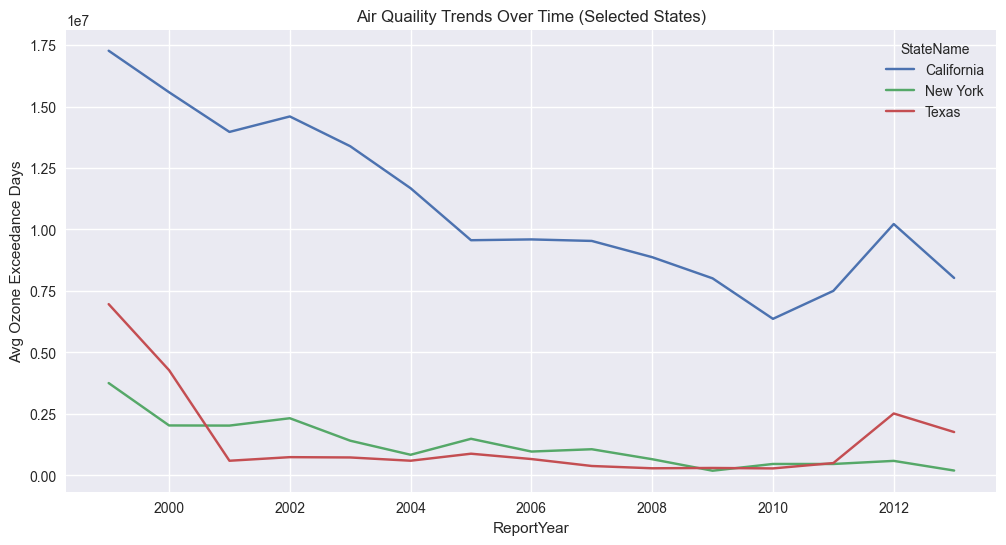

In [25]:
state_year = df.groupby(["StateName", "ReportYear"])["Value"].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(
    data = state_year[state_year["StateName"].isin(["California", "Texas", "New York"])],
    x="ReportYear",
    y="Value",
    hue="StateName"
)

plt.title("Air Quaility Trends Over Time (Selected States)")
plt.ylabel("Avg Ozone Exceedance Days")
plt.show()

## Preliminary Research Questions

1. Can historical air quality patterns at the county level be used to forecast future high-risk periods?
2. Are there persistent geographic clusters of poor air quality across decades?
3. How does variability in monitoring coverage affect observed pollution trends?
4. Can counties be categorized into risk profiles using unsupervised learning?
5. How early can abnormal pollution patterns be detected using time-series models?

These questions open the door for:
- Time-series forecasting
- Spatial modeling
- Clustering and representation learning
- Public health risk assessment
